In [92]:
import numpy as np
import pandas as pd
import arviz as az
from matplotlib import pyplot as plt
import matplotlib.gridspec as gridspec
from cmdstanpy import CmdStanModel
from sampler import CycloneSampler, CycloneDataSimulator

In [111]:
def plot_parameter_estimation_mcmc(Sampler, DataSimulator, param_names, N_obs):
    N_samples = len(Sampler.alpha_draws)

    # save real parameters
    true_params = [
        DataSimulator.sig2,
        DataSimulator.Beta,
        DataSimulator.tau2,
        DataSimulator.alpha, 
        DataSimulator.gamma,
        DataSimulator.nu,
        DataSimulator.lam
    ]
    true_params_flat = np.concatenate([np.atleast_1d(p).flatten() for p in true_params])
    all_param_draws = np.vstack([
        Sampler.sig2_draws.T,
        Sampler.Beta_draws.reshape(N_samples, -1).T,
        Sampler.tau2_draws.T,
        Sampler.alpha_draws, 
        Sampler.gamma_draws,
        Sampler.nu_draws.T,
        Sampler.lam_draws.T,
    ])

    unscaled_param_draws = all_param_draws.copy()

    param_stds = all_param_draws.std(axis=1)
    all_param_draws = ((all_param_draws.T - true_params_flat) / param_stds).T

    # I got help from Claude to make this plot because I didn't know how to plot all the parameters together in a nice way
    fig = plt.figure(figsize=(14, 7))
    fig.suptitle(f"Convergence of Posterior Parameter Draws, n={N_obs} simulated observations",
                fontsize=13, fontweight='bold', y=1.01)
    ax = fig.add_subplot(111)

    # --- Boxplot ---
    ax.boxplot(
        all_param_draws.T,
        tick_labels=param_names,
        whis=(5, 95),
        showfliers=False,
        medianprops=dict(color='steelblue', linewidth=1.5),
        boxprops=dict(color='steelblue'),
        whiskerprops=dict(color='steelblue'),
        capprops=dict(color='steelblue'),
    )
    ax.axhline(0, color='red', linestyle='--', linewidth=1, label='True value')
    ax.set_ylabel("Std. Deviations from True Value", fontsize=10)
    ax.tick_params(axis='x', rotation=90)
    ax.legend(fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.set_xlim(0.5, len(param_names) + 0.5)
        
    plt.show()

    return true_params_flat, unscaled_param_draws

Test sensitivity of our MCMC implementation.

In [94]:
# prior parameters (for sampling data)
a = 3
y_alpha = 3
z_alpha = 2
y_gamma = 3
z_gamma = 2 
v2 = 2
y_lam = 3
z_lam = 1

# model parameters
B = 3               # number of ocean basins
D = 5               # number of predictors

In [95]:
N_small = 100             # number of observations

# simulate N observations from the model
DataSimulator = CycloneDataSimulator(
    B = B,
    a = a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma,
    v2=v2,
    y_lam=y_lam, z_lam=z_lam
)
DataSimulator.generate_X(N_sim=N_small)
X = DataSimulator.X 
basins = DataSimulator.basins
W = DataSimulator.simulate()

# save real parameters
real_params = [
    DataSimulator.sig2,
    DataSimulator.Beta,
    DataSimulator.tau2,
    DataSimulator.alpha, 
    DataSimulator.gamma,
    DataSimulator.nu,
    DataSimulator.lam
]

# load simulated data into a Stan dictionary
# stan_basins = basins + 1            # Stan is 1-indexed!!!
# stan_data = {
#     "N" : N_small, "B" : B, "D" : D,
#     "W" : W, "X" : X, "basins" : stan_basins,
#     "a" : a,
#     "y_alpha" : y_alpha, "z_alpha" : z_alpha,
#     "y_gamma" : y_gamma, "z_gamma" : z_gamma,
#     "v2" : v2,
#     "y_lambda" : y_lam, "z_lambda" : z_lam,
# }

# get results using our own MCMC implementation
SmallSampler = CycloneSampler(
    W = W, X = X, basins = basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma, 
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=B
)
SmallSampler.sample(30_000, init_state=real_params)

In [96]:
N_big = 1500             # number of observations

# simulate N observations from the model
W = DataSimulator.redraw(N_big)
X = DataSimulator.X 
basins = DataSimulator.basins

# load simulated data into a Stan dictionary
# stan_basins = basins + 1            # Stan is 1-indexed!!!
# stan_data = {
#     "N" : N_small, "B" : B, "D" : D,
#     "W" : W, "X" : X, "basins" : stan_basins,
#     "a" : a,
#     "y_alpha" : y_alpha, "z_alpha" : z_alpha,
#     "y_gamma" : y_gamma, "z_gamma" : z_gamma,
#     "v2" : v2,
#     "y_lambda" : y_lam, "z_lambda" : z_lam,
# }

# get results using our own MCMC implementation
BigSampler = CycloneSampler(
    W = W, X = X, basins = basins,
    a=a,
    y_alpha=y_alpha, z_alpha=z_alpha,
    y_gamma=y_gamma, z_gamma=z_gamma, 
    y_lam=y_lam, z_lam=z_lam,
    v2=v2,
    B=B
)
BigSampler.sample(30_000, init_state=real_params)

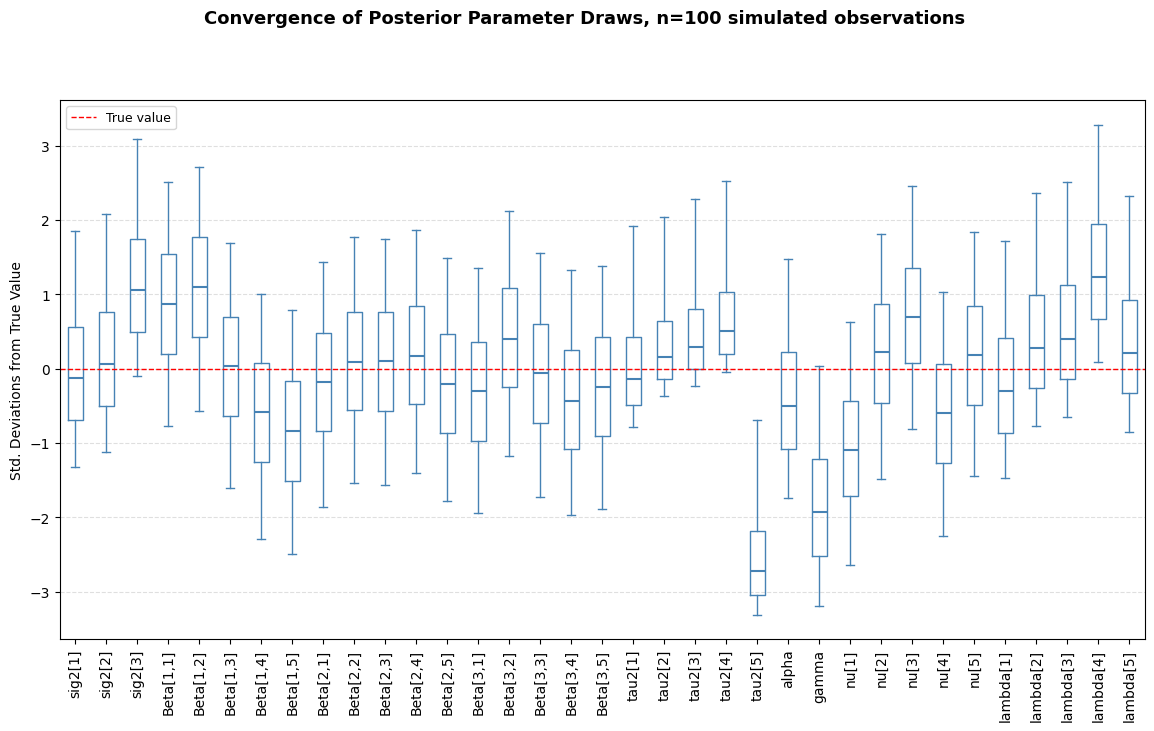

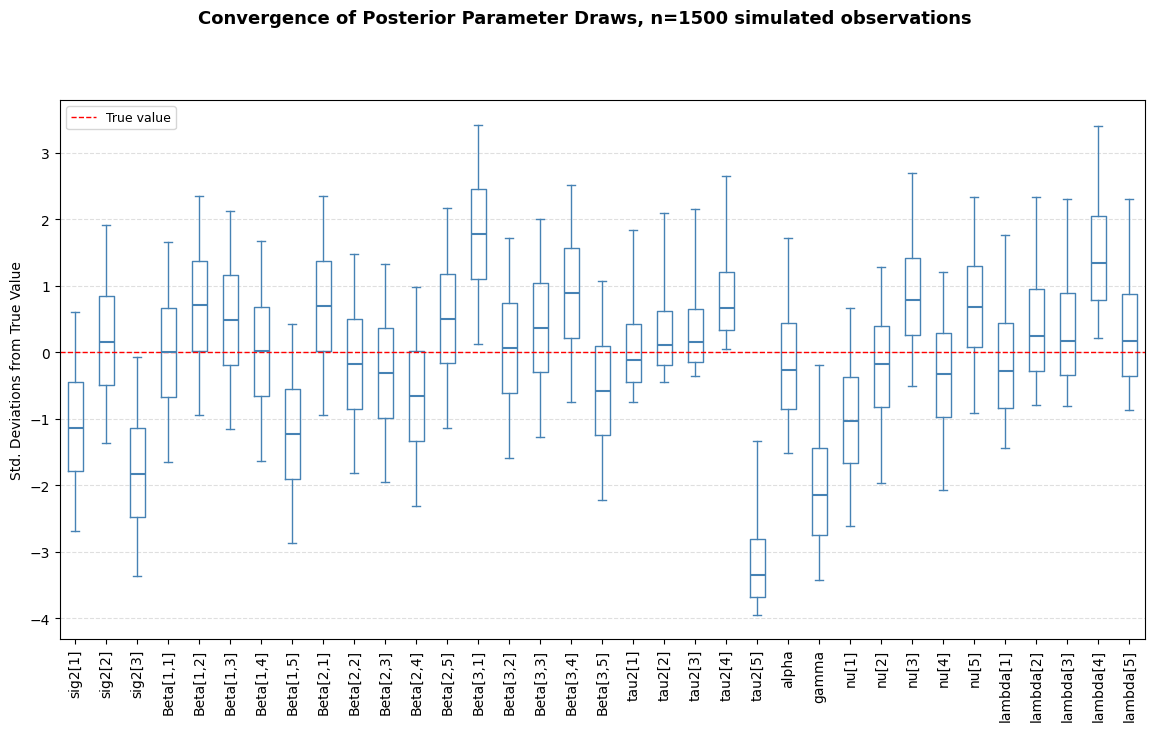

In [112]:
param_names = [f"sig2[{b}]" for b in range(1, B+1)] + [f"Beta[{b},{d}]" for b in range(1, B+1) for d in range(1, D+1)] + [f"tau2[{d}]" for d in range(1, D+1)] + ["alpha", "gamma"] + [f"nu[{d}]" for d in range(1, D+1)] + [f"lambda[{d}]" for d in range(1, D+1)]

true_params, draws_small = plot_parameter_estimation_mcmc(SmallSampler, DataSimulator, param_names, N_small)
_, draws_big = plot_parameter_estimation_mcmc(BigSampler, DataSimulator, param_names, N_big)

In [116]:
# tabulate results
small_parameter_estimation = pd.DataFrame({
    "True Value" : true_params,
    "Posterior Mean" : draws_small.mean(axis=1),
    "Posterior STD" : draws_small.std(axis=1),
    "Posterior 5-th Percentile" : np.percentile(draws_small, 5, axis=1),
    "Posterior 95-th Percentile" : np.percentile(draws_small, 95, axis=1),
})

big_parameter_estimation = pd.DataFrame({
    "True Value" : true_params,
    "Posterior Mean" : draws_big.mean(axis=1),
    "Posterior STD" : draws_big.std(axis=1),
    "Posterior 5-th Percentile" : np.percentile(draws_big, 5, axis=1),
    "Posterior 95-th Percentile" : np.percentile(draws_big, 95, axis=1),
})

In [117]:
small_parameter_estimation

,True Value,Posterior Mean,Posterior STD,Posterior 5-th Percentile,Posterior 95-th Percentile
0,2.303413,2.315610,0.605213,1.504360,3.423857
1,5.412897,5.723239,1.467415,3.765312,8.458775
2,2.735219,4.057880,1.092308,2.621810,6.101136
3,-1.943865,-1.730583,0.244724,-2.132512,-1.329260
4,0.674578,1.416703,0.681327,0.282869,2.519111
5,-2.727562,-2.708677,0.584598,-3.667822,-1.743870
6,0.142872,-0.547868,1.140103,-2.466376,1.285171
7,0.235019,-0.379800,0.732603,-1.587824,0.810957
8,1.049488,0.972022,0.410288,0.288727,1.640413
9,1.826968,1.919670,0.899522,0.448430,3.415569


In [114]:
big_parameter_estimation

,True Value,Posterior Mean,Posterior STD,Posterior 5-th Percentile,Posterior 95-th Percentile
0,2.303413,2.153402,0.136348,1.937398,2.385243
1,5.412897,5.480342,0.346760,4.937216,6.075737
2,2.735219,2.457077,0.155712,2.211570,2.723555
3,-1.943865,-1.943764,0.067232,-2.054444,-1.832454
4,0.674578,0.832039,0.225531,0.460668,1.202543
5,-2.727562,-2.637010,0.186462,-2.942319,-2.331121
6,0.142872,0.146668,0.330765,-0.397976,0.694028
7,0.235019,-0.021482,0.208497,-0.362575,0.324259
8,1.049488,1.121863,0.104133,0.951108,1.293723
9,1.826968,1.768638,0.329465,1.228212,2.311708


Conclusions:
- Due to the large number of parameters, the model needs a large number of observations (ideally 500+ per ocean basin) in order to converge well.
- With a large number of observations, the posterior parameter draws almost always capture the true value within the 95% credible region.
- When given a large number of observations, the posterior standard deviation shrinks significantly.
- The model recovers predictor-specific parameters more accurately when we choose to model a larger number of ocean basins. However, we are limited to 3 because this is what our data reflects. This is one inherent weakness in the identifiability of our model. 